# SVP Observation Converter

This notebook inspects the `obs_seq` file created by the DART SVP converter.  
The converter itself should be run from the terminal. This notebook focuses on reading, summarizing, and visualizing the output observations.

## Objectives

In this notebook you will learn how to:

- Read a DART `obs_seq` file using pyDARTdiags
- Inspect observation types and metadata
- Visualize observations on a map
- Examine temporal coverage
- Compute basic observation statistics

## 1. Import Python libraries

In [33]:
import pydartdiags.obs_sequence.obs_sequence as obsq

import os
import cmocean
import numpy             as np
import pandas            as pd
import cartopy.crs       as ccrs
import cartopy.feature   as cfeature
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates

from pathlib              import Path
from pydartdiags.stats    import stats
from pydartdiags.matplots import matplots as mp

## 2. Define paths

In [34]:
# Path to DART repo (directory) 
basedir = Path(f"/glade/derecho/scratch/{os.environ['USER']}/inacawo/DART_training")

# Path to the SVP converter
svp_dir = basedir / 'observations' / 'obs_converters' / 'SVP' 

# Path to the obs_seq file
obs_seq_file = svp_dir / 'work' / 'obs_seq.svp'
print(f"obs_seq file: {obs_seq_file}")

# Make sure the obs_Seq file exists
assert obs_seq_file.exists(), 'obs_seq file not found'

obs_seq file: /glade/derecho/scratch/gharamti/inacawo/DART_training/observations/obs_converters/SVP/work/obs_seq.svp


## 3. Read the obs_seq file

In [35]:
# Read the obs seq file into a DataFrame
obs = obsq.ObsSequence(obs_seq_file)

# Uncomment to inspect available methods/attributes
# help(obs)

## 4. Preview the observation table

In [36]:
# Examine the file
print(f"DataFrame shape: {obs.df.shape}")
print('\n')

display(obs.df.head())

# To view everything
# obs_seq.df
# obs_seq.all_obs

DataFrame shape: (72, 15)




,obs_num,observation,QC,linked_list,longitude,latitude,vertical,vert_unit,type,metadata,external_FO,seconds,days,time,obs_err_var
0,1,27.110000,0.0,-1 2 -1,134.5074,-5.3896,0.0,surface (m),DRIFTER_TEMPERATURE,[],[],36000,155141,2025-10-06 10:00:00,0.04
1,2,0.000000,0.0,1 3 -1,134.5074,-5.3896,0.0,surface (m),DRIFTER_U_CURRENT_COMPONENT,[],[],36000,155141,2025-10-06 10:00:00,0.01
2,3,0.006144,0.0,2 4 -1,134.5074,-5.3896,0.0,surface (m),DRIFTER_V_CURRENT_COMPONENT,[],[],36000,155141,2025-10-06 10:00:00,0.01
3,4,26.440000,0.0,3 5 -1,51.8492,-26.5184,0.0,surface (m),DRIFTER_TEMPERATURE,[],[],36000,155141,2025-10-06 10:00:00,0.04
4,5,0.127361,0.0,4 6 -1,51.8492,-26.5184,0.0,surface (m),DRIFTER_U_CURRENT_COMPONENT,[],[],36000,155141,2025-10-06 10:00:00,0.01


## 5. Summarize the observation sequence

In [37]:
print("*" * 16)
print("obs_seq SUMMARY:")
print("*" * 16)

print(f"\nNumber of observations : {len(obs.df)}")
print(f"Number of obs types    : {len(obs.types)}")

# Available observation types in the obs_seq file 
# Each type is associated with a DART idenitifier number
print("\nObservation types:")
for kind, name in obs.types.items():
    print(f"  {kind:3d} : {name}")

# Number of copies in the obs_seq 
# observation, QC, .. could be more especially after assimilation 
print("\nObservation copies:")
for i, name in enumerate(obs.copie_names):
    print(f"  {i:2d} : {name}")

# Number of QCs
print("\nQC copies:")
for i, name in enumerate(obs.qc_copie_names):
    print(f"  {i:2d} : {name}")

display(
    obs.df["type"]
    .value_counts()
    .rename_axis("Observation Type")
    .to_frame("Count")
)


****************
obs_seq SUMMARY:
****************

Number of observations : 72
Number of obs types    : 3

Observation types:
   17 : DRIFTER_U_CURRENT_COMPONENT
   18 : DRIFTER_V_CURRENT_COMPONENT
   20 : DRIFTER_TEMPERATURE

Observation copies:
   0 : observation
   1 : QC

QC copies:
   0 : QC


,Count
Observation Type,
DRIFTER_TEMPERATURE,24
DRIFTER_U_CURRENT_COMPONENT,24
DRIFTER_V_CURRENT_COMPONENT,24


## 6. Observation locations by type
The maps below show the locations and values of the different observation types in the `obs_seq` file.  

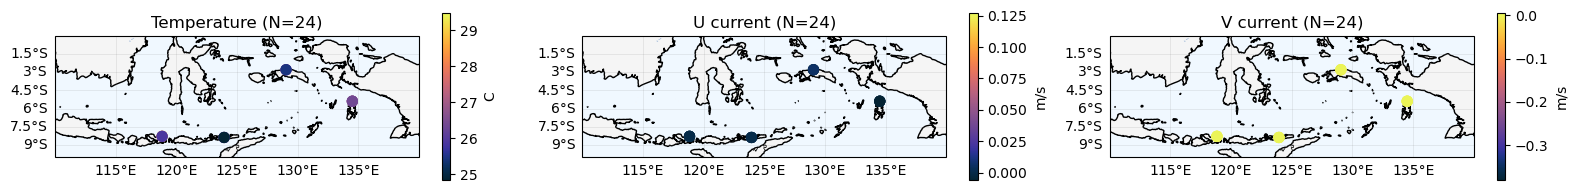

In [38]:
df = obs.df.copy()

# Define obs info as a list of tuples to use for plotting
plot_specs = [
    ("DRIFTER_TEMPERATURE"        , "Temperature", "C"  , cmocean.cm.thermal),
    ("DRIFTER_U_CURRENT_COMPONENT", "U current"  , "m/s", cmocean.cm.thermal),
    ("DRIFTER_V_CURRENT_COMPONENT", "V current"  , "m/s", cmocean.cm.thermal),
]

# Define the cartopy projection: standard. un-projected Equidistant 
# Cylindrical coordinate system (lons, lats mapped to 2D cartesian grid)
proj = ccrs.PlateCarree()

# We will plot a figure containing 3 different plots (maps)
fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 7),
    sharey=True,
    subplot_kw={"projection": proj}
)

# Loop over figure specs:
# ax: current axis; obs_type: T, U, V; cmap: colormap style
for ax, (obs_type, title, label, cmap) in zip(axes, plot_specs):

    # subset dataframe by observation type
    # i.e., only get data for each obs type
    this_ob = df[df["type"] == obs_type]

    ax.coastlines(resolution="10m")
    ax.add_feature(cfeature.OCEAN, facecolor="aliceblue")
    ax.add_feature(cfeature.LAKES, facecolor="lightsteelblue")
    ax.add_feature(cfeature.LAND, zorder=0, linewidth=0.5, facecolor="whitesmoke")
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    sc = ax.scatter(
        this_ob["longitude"],
        this_ob["latitude"],
        c=this_ob["observation"],
        s=50,
        cmap=cmap,
        transform=proj,
        zorder=5,
    )

    plt.colorbar(sc, ax=ax, label=label, shrink=0.25)

    ax.set_extent([110, 140, -10, 0], crs=proj)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.2)
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(f"{title} (N={len(this_ob)})")

# plt.suptitle("SVP Observations by Type", fontsize=18)
plt.tight_layout()
plt.show()

## 7. Temporal Coverage

At each analysis time there are observations from several drifters. The time-series plotsrepresent the collection of all observations available at each time rather than the trajectory of a single platform.


Temperature
time
2025-10-06 10:00:00    5
2025-10-06 11:00:00    5
2025-10-06 12:00:00    5
2025-10-06 13:00:00    5
2025-10-06 14:00:00    4
dtype: int64

U current
time
2025-10-06 10:00:00    5
2025-10-06 11:00:00    5
2025-10-06 12:00:00    5
2025-10-06 13:00:00    5
2025-10-06 14:00:00    4
dtype: int64

V current
time
2025-10-06 10:00:00    5
2025-10-06 11:00:00    5
2025-10-06 12:00:00    5
2025-10-06 13:00:00    5
2025-10-06 14:00:00    4
dtype: int64


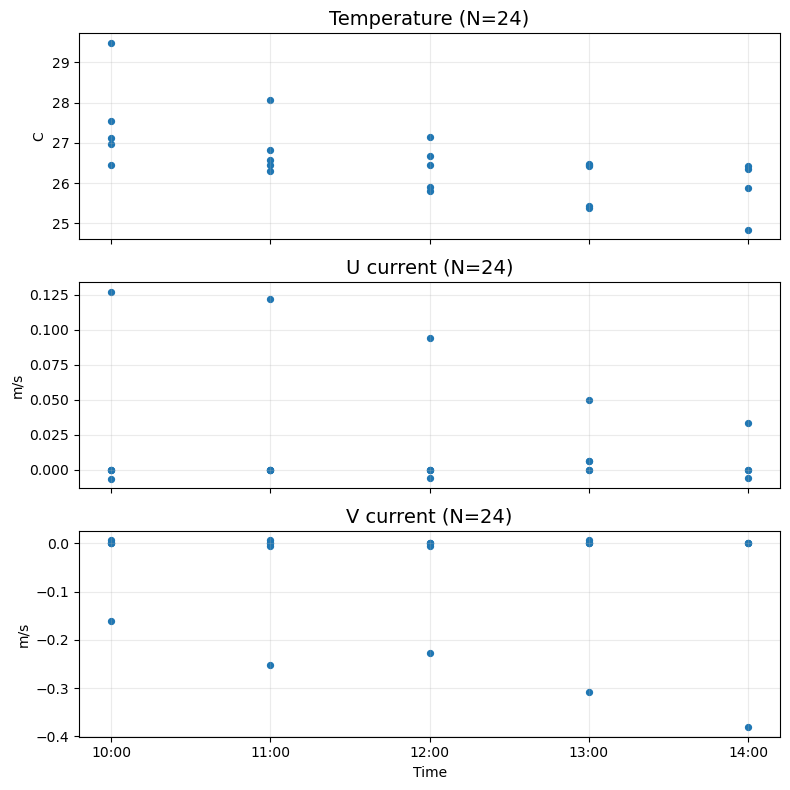

In [39]:
for obs_type, title, _, _ in plot_specs:

    this_ob = df[df["type"] == obs_type]

    print(f"\n{title}")
    print(this_ob.groupby("time").size())

fig, axes = plt.subplots(
    nrows=len(plot_specs),
    ncols=1,
    figsize=(8, 8),
    sharex=True,
)

for ax, (obs_type, title, ylabel, cmap) in zip(axes, plot_specs):

    this_ob = df[df["type"] == obs_type].sort_values("time")

    ax.scatter(
        this_ob["time"],
        this_ob["observation"],
        s=18,
    )

    ax.set_ylabel(ylabel)
    ax.set_title(f"{title} (N={len(this_ob)})", fontsize=14)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("Time")

# Format time axis
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=1))

plt.tight_layout()
plt.show()

## 8. Observations Statistics

In [40]:
print("Observation time range:")
print(df["time"].min())
print(df["time"].max())

print("\nLongitude range:")
print(f"{df['longitude'].min():.2f} {df['longitude'].max():.2f}")

print("\nLatitude range:")
print(f"{df['latitude'].min():.2f} {df['latitude'].max():.2f}")

print("\n")

summary = []

for obs_type, title, units, _ in plot_specs:

    this_ob = df[df["type"] == obs_type]

    summary.append({
        "Type" : title,
        "Count": len(this_ob),
        "Min"  : this_ob["observation"].min(),
        "Max"  : this_ob["observation"].max(),
        "Mean" : this_ob["observation"].mean(),
        "Std"  : this_ob["observation"].std(),
    })

display(pd.DataFrame(summary))

Observation time range:
2025-10-06 10:00:00
2025-10-06 14:00:00

Longitude range:
51.85 134.51

Latitude range:
-26.56 -2.80




,Type,Count,Min,Max,Mean,Std
0,Temperature,24,24.840000,29.490000,26.559167,0.932085
1,U current,24,-0.006177,0.127361,0.017508,0.039748
2,V current,24,-0.381632,0.006144,-0.055142,0.115862


## Key Takeaways

- The SVP converter creates temperature and velocity observations.
- Observations are stored in DART `obs_seq` format.
- pyDARTdiags can be used to inspect and visualize the observations.
- Multiple drifters may report at the same analysis time.
- Observation values, locations, and errors should always be checked before assimilation.